# Prolegômenos

Disciplina de Inteligência Artificial (IA)

Projeto Parte I

Desafio: Criação de um Data Storytelling com Machine Learning.

Instruções:
1. Dividam-se em times (Grupos de 4 – 5 pessoas!);
2. Selecionem um conjunto de dados de sua preferência (Dados Reais!! Dados Recife, Dados Gov, Kaggle);
3. A partir dele, implemente todas as principais etapas que conversamos até aqui: Coleta de dados, pré-processamento, análises, visualizações e machine learning. Monte seu projeto no Google Colab.
4. Apresente o projeto desenvolvido.

Equipe:
* Mariana Duarta
* Naeldy Godoy
* Luiz Felipe Florêncio
* João Cecílio
* Guilherme Vieira

<br>
<br>
<br>
<br>
<br>

# Contexto

A Governadora do Estado de Pernambuco solicitou uma **análise das principais reclamações sobre problemas energia elétrica**, com o intuito de **comparar o desempenho do estado de Pernambuco com os demais estados do Nordeste** e **identificar as principais queixas** da população.

A demanda foi motivada pelo alto índice de quedas de energia registrado no estado, afetando diretamente a qualidade do serviço prestado à população.

O objetivo é identificar possíveis falhas ou áreas de melhoria, de forma que se possa solicitar à prestadora de serviços a implementação de melhorias, garantindo à população pernambucana um atendimento de qualidade, que atenda de maneira eficiente as expectativas tanto do governo estadual quanto dos cidadãos.

Desse modo, a ANEEL (Agência Nacional de Energia Elétrica), autarquia em regime especial vinculada ao Ministério de Minas e Energia, foi criada para regular o setor elétrico brasileiro.

Os dados públicos fornecidos pela ANEEL, por meio da Ouvidoria Setorial, referem-se aos registros de manifestações feitas por consumidores do serviço público de energia elétrica em todo o país.

Esses dados englobam reclamações, solicitações, denúncias e elogios relacionados à prestação do serviço pelas distribuidoras de energia.

A Ouvidoria Setorial atua como um canal institucional direto entre a sociedade e a ANEEL, especialmente nos casos em que os consumidores não conseguem resolver suas demandas junto às concessionárias.

fonte dos dados: https://dadosabertos.aneel.gov.br/dataset/ouvidoria-setorial-aneel

Dicionário de dados: https://dadosabertos.aneel.gov.br/dataset/1206d323-ad8c-46c6-bc2d-9b731e42ee26/resource/9b01f108-34c1-45d2-a8c9-0aeb19905257/download/dm-ouvidoriaaneel.pdf

<br>
<br>
<br>
<br>
<br>

# Compreensão e Tratamento dos Dados


In [42]:
# Importações

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.neighbors import LocalOutlierFactor
# from sklearn.metrics import classification_report
# from sklearn.ensemble import IsolationForest
# from sklearn.svm import OneClassSVM

!pip install pyod
from pyod.models.lof import LOF
from sklearn.preprocessing import StandardScaler

<br>
<br>
<br>
<br>
<br>
Carregamento e concatenação dos datasets

In [43]:
# dataset de produção
datasets_geral = ['ouvidoria-aneel-2015.csv', 'ouvidoria-aneel-2016.csv', 'ouvidoria-aneel-2017.csv', 'ouvidoria-aneel-2018.csv', 'ouvidoria-aneel-2019.csv',
            'ouvidoria-aneel-2020.csv', 'ouvidoria-aneel-2021.csv', 'ouvidoria-aneel-2022.csv', 'ouvidoria-aneel-2023.csv', 'ouvidoria-aneel-2024.csv']

# dataset para homologação
# datasets = ['ouvidoria-aneel-2016.csv', 'ouvidoria-aneel-2019.csv', 'ouvidoria-aneel-2022.csv', 'ouvidoria-aneel-2024.csv']
datasets = ['ouvidoria-aneel-2022.csv', 'ouvidoria-aneel-2023.csv', 'ouvidoria-aneel-2024.csv']

dataframes = []

# Loop para ler os arquivos
for file in datasets:
    df = pd.read_csv(file, sep=';', encoding='latin1')
    df['ano'] = file[-8:-4]  # adiciona uma coluna com o ano, extraído do nome do arquivo
    dataframes.append(df)

# Concatena todos os DataFrames
df_completo = pd.concat(dataframes, ignore_index=True)


# TESTE
# df_completo = pd.read_csv('ouvidoria-aneel-2024.csv', sep=';', encoding='latin1')
# df_completo['ano'] = 2024

# Exibe as primeiras linhas do DataFrame combinado
df_completo.head()

,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,DscSituacao,DtCriacao,NumQtdReclamacoesDia,ano
0,2023-12-01,Energisa AC,4065033000170,AC,1200450.0,Senador Guiomard,Informação,Atendimento,Atend Digital,Sem decisão,Finalizada por Script,2022-12-02,1,2022
1,2023-12-01,Energisa AC,4065033000170,AC,1200401.0,Rio Branco,Informação,Atendimento,Atend Telefônico,Sem decisão,Finalizada por Script,2022-10-04,1,2022
2,2023-12-01,Energisa AC,4065033000170,AC,1200203.0,Cruzeiro do Sul,Informação,Cobranças,Cobrança Irregularidades,Sem decisão,Encerrada,2022-08-05,1,2022
3,2023-12-01,Energisa AC,4065033000170,AC,1200401.0,Rio Branco,Informação,Atendimento,Atend Presencial,Sem decisão,Finalizada por Script,2022-02-10,1,2022
4,2023-12-01,Energisa AC,4065033000170,AC,1200401.0,Rio Branco,Informação,Cobranças,Cobrança Irregularidades,Sem decisão,Encerrada,2022-04-15,1,2022


<br>
<br>
<br>
<br>
<br>
Dimensões do dataframe.
Considerando que são dados de 3 anos diferentes.

In [44]:
df_completo.shape

(1511770, 14)

<br>
<br>
<br>
<br>
<br>
Contabilidade por ano

In [45]:
# distinção de registros por ano
print(df_completo['ano'].value_counts())

ano
2023    540653
2024    499311
2022    471806
Name: count, dtype: int64


<br>
<br>
<br>
<br>
<br>
Seleção dos Estados do nordeste

In [46]:
# Recorte para apenas Estados do nordeste

estados_nordeste = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
df_NE = df_completo[df_completo['SigUF'].isin(estados_nordeste)]

print(df_NE['SigUF'].value_counts())

SigUF
PE    160924
BA    154080
CE    114115
RN     33722
AL     25292
MA     18723
PI     18578
PB     11810
SE      5422
Name: count, dtype: int64


In [47]:
# dimensões do datarame apenas com dados do nordeste
df_NE.shape

(542666, 14)

<br>
<br>
<br>
<br>
<br>
Aferição de valores nulos ou ausentes

In [48]:
print(df_NE.isnull().sum())

DatGeracaoConjuntoDados    0
SigAgente                  0
NumCPFCNPJAgente           0
SigUF                      0
CodigoMunicipio            0
NomMunicipio               1
NomCategoria               2
NomSubCategoria            2
NomTipologia               2
NomDecisao                 0
DscSituacao                0
DtCriacao                  0
NumQtdReclamacoesDia       0
ano                        0
dtype: int64


<br>
<br>
<br>
<br>
<br>
Aferição dos Tipos de Dados por Variável

In [49]:
print(df_NE.dtypes)

DatGeracaoConjuntoDados     object
SigAgente                   object
NumCPFCNPJAgente             int64
SigUF                       object
CodigoMunicipio            float64
NomMunicipio                object
NomCategoria                object
NomSubCategoria             object
NomTipologia                object
NomDecisao                  object
DscSituacao                 object
DtCriacao                   object
NumQtdReclamacoesDia         int64
ano                         object
dtype: object


<br>
<br>
<br>
<br>
<br>
Criação de colunas para individualizar das marcações de data e Tratamento de tipos

In [50]:
# Certifique-se de que a coluna DtCriacao está no formato datetime
df_NE['DtCriacao'] = pd.to_datetime(df_NE['DtCriacao'])

# Criar a coluna com o número do mês
df_NE['Mes_Numero'] = df_NE['DtCriacao'].dt.month

# Criar a coluna com o nome do mês
import calendar
df_NE['Mes_Nome'] = df_NE['DtCriacao'].dt.month.apply(lambda x: calendar.month_name[x])

# Criar a coluna com o dia do mês
df_NE['Dia'] = df_NE['DtCriacao'].dt.day

df_NE.head()

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\142491585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NE['DtCriacao'] = pd.to_datetime(df_NE['DtCriacao'])
C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\142491585.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NE['Mes_Numero'] = df_NE['DtCriacao'].dt.month
C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\142491585.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,DscSituacao,DtCriacao,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia
1951,2023-12-01,Equatorial MA,6272793000184,MA,2100055.0,Açailândia,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-03-30,1,2022,3,March,30
1952,2023-12-01,Equatorial MA,6272793000184,MA,2111300.0,São Luís,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-05-27,1,2022,5,May,27
1953,2023-12-01,Equatorial MA,6272793000184,MA,2111300.0,São Luís,Denúncias,Denúncias,Contra Concessionárias,Sem decisão,Encerrada distribuidora,2022-09-15,1,2022,9,September,15
1954,2023-12-01,Equatorial MA,6272793000184,MA,2112456.0,Turilândia,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-02-18,1,2022,2,February,18
1955,2023-12-01,Equatorial MA,6272793000184,MA,2111409.0,São Luís Gonzaga do Maranhão,Informação,Atendimento,Atend Digital,Sem decisão,Finalizada por Script,2022-03-29,1,2022,3,March,29


In [51]:
# converter o ano para tipo integer
df_NE['ano'] = df_NE['ano'].astype(int)

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\3917068169.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NE['ano'] = df_NE['ano'].astype(int)


In [52]:
# Ajuste no formato da data para dd/mm/aaaa

df_NE['DatGeracaoConjuntoDados'] = pd.to_datetime(df_NE['DatGeracaoConjuntoDados']).dt.strftime('%d/%m/%Y')
df_NE.head(5)

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\579543805.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NE['DatGeracaoConjuntoDados'] = pd.to_datetime(df_NE['DatGeracaoConjuntoDados']).dt.strftime('%d/%m/%Y')


,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,DscSituacao,DtCriacao,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia
1951,01/12/2023,Equatorial MA,6272793000184,MA,2100055.0,Açailândia,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-03-30,1,2022,3,March,30
1952,01/12/2023,Equatorial MA,6272793000184,MA,2111300.0,São Luís,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-05-27,1,2022,5,May,27
1953,01/12/2023,Equatorial MA,6272793000184,MA,2111300.0,São Luís,Denúncias,Denúncias,Contra Concessionárias,Sem decisão,Encerrada distribuidora,2022-09-15,1,2022,9,September,15
1954,01/12/2023,Equatorial MA,6272793000184,MA,2112456.0,Turilândia,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-02-18,1,2022,2,February,18
1955,01/12/2023,Equatorial MA,6272793000184,MA,2111409.0,São Luís Gonzaga do Maranhão,Informação,Atendimento,Atend Digital,Sem decisão,Finalizada por Script,2022-03-29,1,2022,3,March,29


<br>
<br>
<br>
<br>
<br>
Uniformizar o estilo de formatação dos nomes dos municípios

In [53]:
df_NE['NomMunicipio'] = df_NE['NomMunicipio'].str.title()

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\2288131043.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NE['NomMunicipio'] = df_NE['NomMunicipio'].str.title()


<br>
<br>
<br>
<br>
<br>
Retirar dados de Brasília que foram erroneamente colocados como PE.

In [54]:
df_NE = df_NE[df_NE['CodigoMunicipio'] != 5300108]

<br>
<br>
<br>
<br>
<br>
Dataframe apenas com dados de Pernambuco

In [55]:
# dataframe apenas com Pernambuco
df_pe = df_NE[df_NE['SigUF'] == 'PE']
num_municipios_pe = df_pe['NomMunicipio'].nunique()

print(f'Número de municípios em Pernambuco: {num_municipios_pe}')

Número de municípios em Pernambuco: 190


<br>
<br>
<br>
<br>
<br>
Alguns ajustes gerais

In [56]:
cores = {
    2022: '#ffe986',
    2023: '#f5bb5b',
    2024: '#fc5b39'
}

<br>
<br>
<br>
<br>
<br>

### Populaçã em Pernambuco

<br>
<br>
<br>
<br>
<br>
Integração com datasets da população pernambucana segundo o censo de 2022

In [57]:
# Carregar o DataFrame
df_populacao = pd.read_csv('br_ibge_populacao_municipio.csv', sep=',', encoding='latin1')

# Apenas Pernambuco
df_populacao_pe = df_populacao[df_populacao['sigla_uf'] == 'PE']

# Data do último censo
df_populacao_pe_2022 = df_populacao_pe[df_populacao_pe['ano'] == 2022]

# Visualizar as primeiras linhas
df_populacao_pe_2022.head()

,ano,sigla_uf,id_municipio,populacao
45348,2022,PE,2600054.0,99331.0
45380,2022,PE,2600104.0,40120.0
45412,2022,PE,2600203.0,16486.0
45444,2022,PE,2600302.0,23739.0
45476,2022,PE,2600401.0,26473.0


<br>
<br>
<br>
<br>
<br>
Incorpora no dataframe principal dados sobre a população em PE

In [58]:
# Converter para inteiros para garantir correspondência exata
df_pe['CodigoMunicipio'] = df_pe['CodigoMunicipio'].astype(int)
df_populacao_pe_2022['id_municipio'] = df_populacao_pe_2022['id_municipio'].astype(int)

# Merge dos dataframes pela coluna de código do município
df_pe = pd.merge(
    df_pe,
    df_populacao_pe_2022[['id_municipio', 'populacao']],  # seleciona apenas o necessário
    left_on='CodigoMunicipio',
    right_on='id_municipio',
    how='left'
)

df_pe.head()

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\17896694.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pe['CodigoMunicipio'] = df_pe['CodigoMunicipio'].astype(int)
C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\17896694.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_populacao_pe_2022['id_municipio'] = df_populacao_pe_2022['id_municipio'].astype(int)


,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,DscSituacao,DtCriacao,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia,id_municipio,populacao
0,01/12/2023,Enel CE,7047251000170,PE,2612505,Santa Cruz Do Capibaribe,Reclamações,Qualidade do Fornecimento,Falta de Energia,Procedente,Encerrada,2022-12-26,1,2022,12,December,26,2612505.0,97386.0
1,01/12/2023,Neoenergia Cosern,8324196000181,PE,2611606,Recife,Reclamações,Faturamento,Class UC,Sem decisão,Encerrada distribuidora,2022-02-04,1,2022,2,February,4,2611606.0,1494586.0
2,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2609600,Olinda,Denúncias,Denúncias,Contra Concessionárias,Improcedente,Encerrada,2022-01-21,1,2022,1,January,21,2609600.0,349920.0
3,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2607901,Jaboatão Dos Guararapes,Denúncias,Denúncias,Ligação Clandestina,Sem decisão,Encerrada distribuidora,2022-02-14,1,2022,2,February,14,2607901.0,653793.0
4,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2607901,Jaboatão Dos Guararapes,Denúncias,Denúncias,Ligação Clandestina,Improcedente,Encerrada,2022-04-18,1,2022,4,April,18,2607901.0,653793.0


<br>
<br>
<br>
<br>
<br>
Apenas Pernambuco e com Falta de Energia

In [59]:
df_pe_falta_energia = df_pe[df_pe['NomTipologia'] == 'Falta de Energia']

df_pe_falta_energia.head()

,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,DscSituacao,DtCriacao,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia,id_municipio,populacao
0,01/12/2023,Enel CE,7047251000170,PE,2612505,Santa Cruz Do Capibaribe,Reclamações,Qualidade do Fornecimento,Falta de Energia,Procedente,Encerrada,2022-12-26,1,2022,12,December,26,2612505.0,97386.0
7158,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2616407,Vitória De Santo Antão,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Encerrada,2022-02-15,1,2022,2,February,15,2616407.0,135182.0
7180,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2609402,Moreno,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Encerrada,2022-06-06,1,2022,6,June,6,2609402.0,54637.0
7188,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2613701,São Lourenço Da Mata,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Encerrada,2022-06-09,1,2022,6,June,9,2613701.0,110765.0
7196,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2613107,São Caitano,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Encerrada,2022-06-25,1,2022,6,June,25,2613107.0,36982.0


<br>
<br>
<br>
<br>
<br>
Apenas Recife e com Falta de Energia

In [60]:
# Apenas Recife e casos de Falta de Energia

df_recife_falta_energia = df_NE[df_NE['NomMunicipio'] == 'Recife']
df_recife_falta_energia = df_recife_falta_energia[df_recife_falta_energia['NomTipologia'] == 'Falta de Energia']

df_recife_falta_energia.head()

,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,DscSituacao,DtCriacao,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia
62930,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2611606.0,Recife,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Encerrada,2022-11-25,1,2022,11,November,25
63122,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2611606.0,Recife,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Finalizada por Script,2022-01-17,2,2022,1,January,17
63186,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2611606.0,Recife,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Finalizada por Script,2022-01-20,3,2022,1,January,20
63217,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2611606.0,Recife,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Finalizada por Script,2022-01-04,1,2022,1,January,4
63289,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2611606.0,Recife,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,Finalizada por Script,2022-01-07,3,2022,1,January,7


<br>
<br>
<br>
<br>
<br>

# Análise Exploratória de Dados

Aferição dos níveis de granularidade das classificações da ANEEL.

<br>
<br>
<br>
<br>
<br>
Aferição das Categorias - Menor Granularidade

In [61]:
categorias_ordenadas = df_NE['NomCategoria'].value_counts().reset_index()
categorias_ordenadas.columns = ['Categorias', 'Quantidade']
categorias_ordenadas.head(10)

,Categorias,Quantidade
0,Informação,416276
1,Reclamações,121328
2,Denúncias,509
3,Elogio,44
4,Sugestão/Crítica,33


<br>
<br>
<br>
<br>
<br>
Aferição das Subcategorias - Granularidade Média

In [62]:
sub_tipologias_ordenadas = df_NE['NomSubCategoria'].value_counts().reset_index()
sub_tipologias_ordenadas.columns = ['Suub_Tipologia', 'Quantidade']
sub_tipologias_ordenadas.head(10)

,Suub_Tipologia,Quantidade
0,Qualidade do Fornecimento,180375
1,Serviços Comerciais,120145
2,Serviços Técnicos,69255
3,Cobranças,68869
4,Faturamento,66554
5,Atendimento,25688
6,Outros,6718
7,Denúncias,509
8,Elogio,44
9,Sugestão/Crítica,33


<br>
<br>
<br>
<br>
<br>
Aferição das Tipologias - Maior granularidade

In [63]:
tipologias_ordenadas = df_NE['NomTipologia'].value_counts().reset_index()
tipologias_ordenadas.columns = ['Tipologia', 'Quantidade']
tipologias_ordenadas.head(20)

,Tipologia,Quantidade
0,Falta de Energia,136519
1,Religação,55670
2,Oscilação de Tensão,30091
3,Ligação,27761
4,Débitos Anteriores,26472
5,Variação de Consumo,23466
6,Extensão de Rede,21148
7,Entrega da Fatura,20183
8,Atend Telefônico,18736
9,Conexão Microgeração,11665


<br>
<br>
<br>
<br>
<br>
**Relação entre Categorias e Tipologias**
A tipologia de 'Falta de Energia' está presente como categoria de 'Informação' ou 'Reclamação', ou seja, o usuário ou o cidadão que classificou tal questão pode ter tido intenções diferentes em relação a um mesmo problema, a falta de energia.

In [64]:
df_NE_informacoes = df_NE[df_NE['NomCategoria'] == 'Informação']
df_NE_reclamacoes = df_NE[df_NE['NomCategoria'] == 'Reclamações']

In [65]:
tipologias_ordenadas_info = df_NE_informacoes['NomTipologia'].value_counts().reset_index()
tipologias_ordenadas_info.columns = ['Tipologia', 'Quantidade']
tipologias_ordenadas_info.head(20)

,Tipologia,Quantidade
0,Falta de Energia,116425
1,Religação,50394
2,Débitos Anteriores,26264
3,Oscilação de Tensão,20389
4,Ligação,18680
5,Atend Telefônico,17719
6,Entrega da Fatura,17287
7,Variação de Consumo,15253
8,Iluminação Pública,9622
9,2ª Via Fatura,9299


In [66]:
tipologias_ordenadas_reclam = df_NE_reclamacoes['NomTipologia'].value_counts().reset_index()
tipologias_ordenadas_reclam.columns = ['Tipologia', 'Quantidade']
tipologias_ordenadas_reclam.head(20)

,Tipologia,Quantidade
0,Falta de Energia,20094
1,Extensão de Rede,12938
2,Oscilação de Tensão,9702
3,Ligação,9081
4,Conexão Microgeração,8740
5,Variação de Consumo,8213
6,Fatur Microgeração,6755
7,Religação,5276
8,Interrup Frequentes,3855
9,Alteração de carga,3687


<br>
<br>
<br>
<br>
<br>
Pernambuco lidera os casos das reclamações como um todo em relação aos demais Estados do nordeste, apresentando forte crescimento em 2023 e 2024.

<Figure size 1200x800 with 0 Axes>

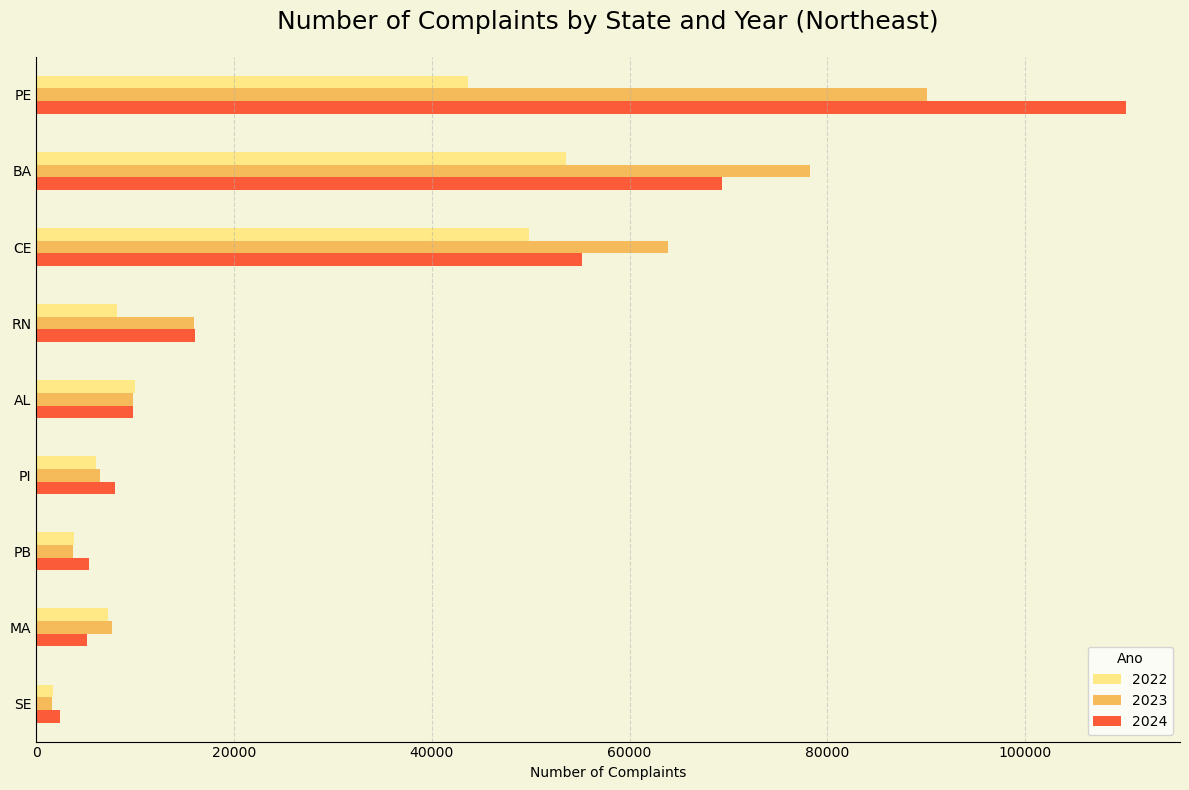

In [67]:
reclamacoes_estado_ano = df_NE.groupby(['SigUF', 'ano'])['NumQtdReclamacoesDia'].sum().unstack()

# order the states based on the total of 2024 (year as string if applicable)
reclamacoes_estado_ano = reclamacoes_estado_ano.sort_values(by=2024, ascending=False)

# list of colors in the same order as the columns (years)
cores_ordenadas = [cores[ano] for ano in reclamacoes_estado_ano.columns]

# horizontal bars
plt.figure(figsize=(12, 8))
reclamacoes_estado_ano.plot(
    kind='barh',
    stacked=False,
    color=cores_ordenadas,
    figsize=(12, 8)
)

plt.title('Number of Complaints by State and Year (Northeast)', fontsize=18, pad=20)
plt.xlabel('Number of Complaints')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().set_facecolor('#f5f5dc') 
plt.gcf().set_facecolor('#f5f5dc')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.legend(title='Ano')
plt.gca().tick_params(axis='x', length=0)
plt.gca().tick_params(axis='y', length=0)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('images/p01_northeast_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

<br>
<br>
<br>
<br>
<br>
Top 10 Tipologias mais frequêntes no Nordeste e por ano.
A 'Falta de Energia' moustrou ser a principal fonte de pedidos de informação e reclamações no nordeste para a ANEEL.

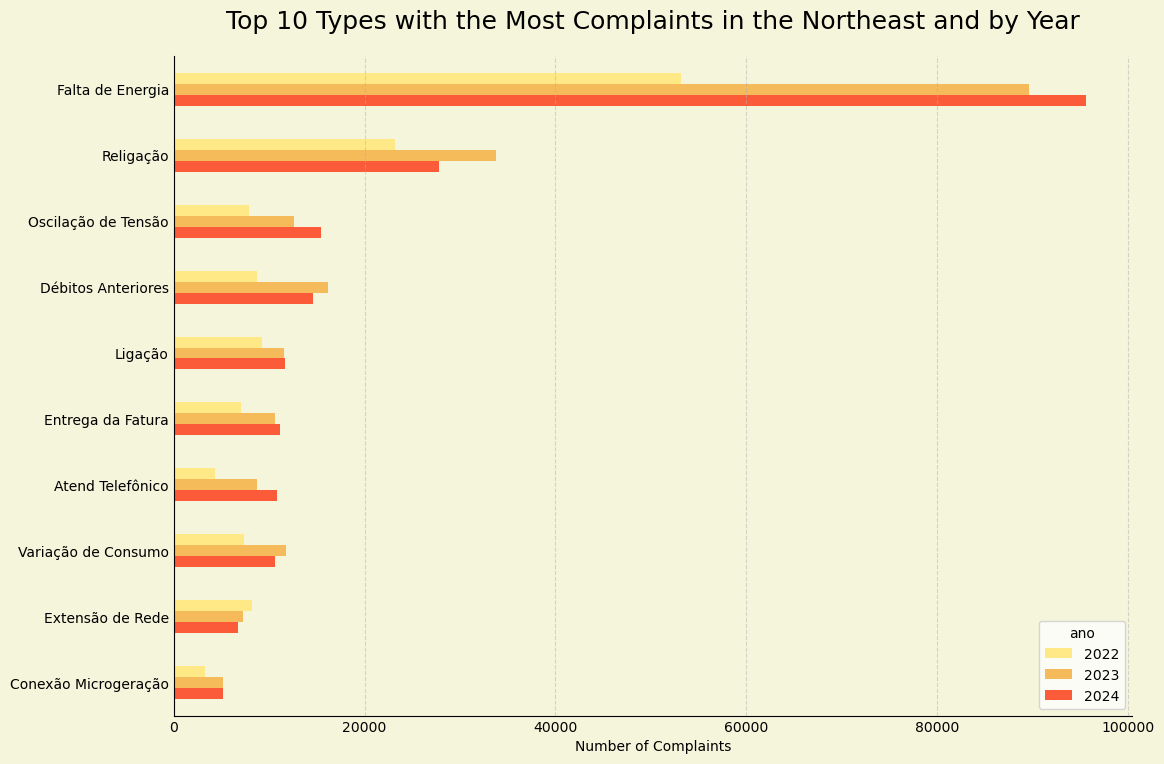

In [68]:
# Agrupar por Tipologia e Ano
tipologia_ano = df_NE.groupby(['NomTipologia', 'ano'])['NumQtdReclamacoesDia'].sum().unstack()

# Selecionar as 10 tipologias com mais reclamações somadas (em todos os anos)
top_10_tipologias = tipologia_ano.sum(axis=1).sort_values(ascending=False).head(10).index

# Filtrar apenas as top 10
tipologia_ano_top10 = tipologia_ano.loc[top_10_tipologias]

# Ordenar do maior para o menor com base em 2024 (ou soma geral, se preferir)
tipologia_ano_top10 = tipologia_ano_top10.sort_values(by=2024, ascending=False)

# Garantir ordenação correta das colunas
tipologia_ano_top10 = tipologia_ano_top10[sorted(tipologia_ano_top10.columns)]
cores_ordenadas = [cores[ano] for ano in sorted(tipologia_ano_top10.columns)]

# Criar figura e eixo
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')  # Fundo da figura

# Plotar gráfico horizontal com cores por ano
tipologia_ano_top10.plot(
    kind='barh',
    stacked=False,
    color=cores_ordenadas,
    ax=ax
)

ax.set_title(
    'Top 10 Types with the Most Complaints in the Northeast and by Year',
    fontsize=18,
    pad=20
)
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('')

ax.invert_yaxis()

# Estética: fundo, grid, spines, ticks
ax.set_facecolor('#ffffff')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.gca().set_facecolor('#f5f5dc') 
plt.gcf().set_facecolor('#f5f5dc') 

plt.tight_layout(pad=2.0)

plt.savefig('images/p02_10_types_northeast_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

<br>
<br>
<br>
<br>
<br>
Pernambuco lidera os casos de reclamação por 'Falta de Energia' no nordeste com crescimento entre 2022 e 2024.
Ao passo que os Estados da Bahia e do Ceará tiveram queda de 2023 para 2024.
Pernambuco tem mais ou menos o dobro da quantidade de reclamações em 2024 em relação a esses dois Estados.

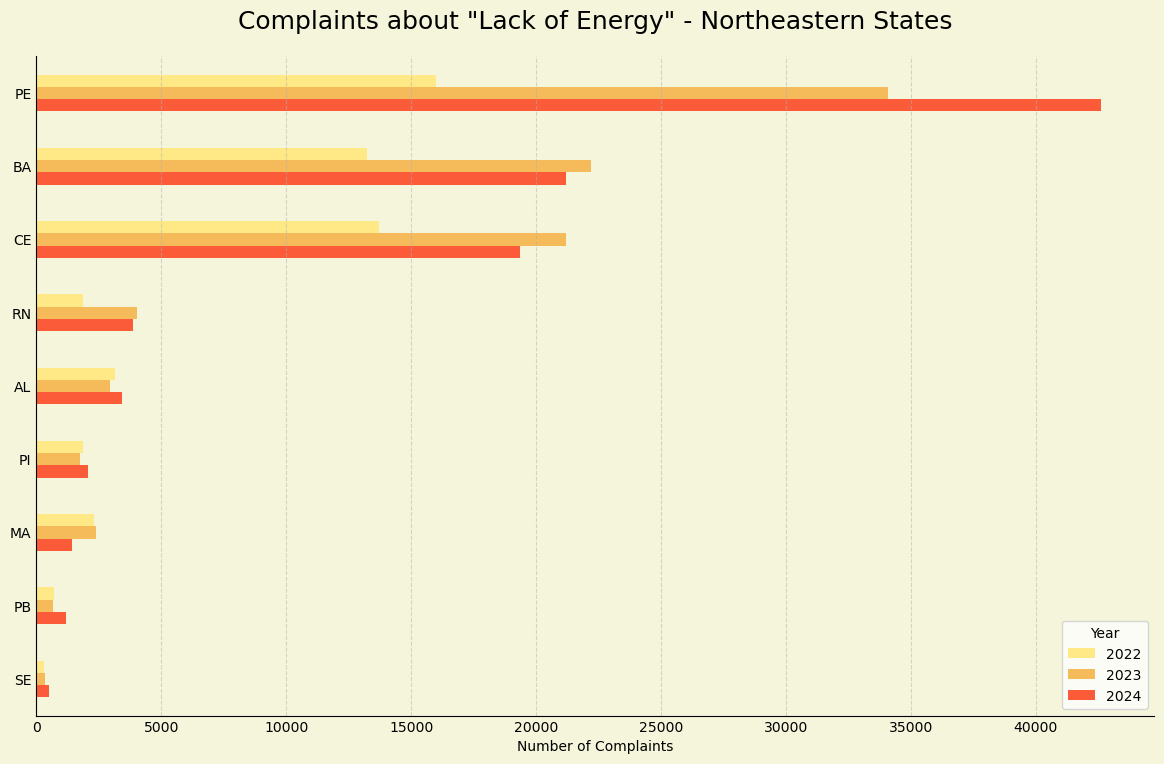

In [69]:
# Filtrar dados de "Falta de Energia"
df_falta_energia_NE = df_NE[df_NE['NomTipologia'] == 'Falta de Energia']

# Agrupar por estado e ano
reclamacoes_falta_energia_ano = df_falta_energia_NE.groupby(['SigUF', 'ano'])['NumQtdReclamacoesDia'].sum().unstack()

# Ordenar os estados com base no total de 2024
reclamacoes_falta_energia_ano = reclamacoes_falta_energia_ano.sort_values(by=2024, ascending=False)

# Garantir que colunas estejam ordenadas corretamente
reclamacoes_falta_energia_ano = reclamacoes_falta_energia_ano[sorted(reclamacoes_falta_energia_ano.columns)]
cores_ordenadas = [cores[ano] for ano in sorted(reclamacoes_falta_energia_ano.columns)]

# Criar figura e eixo
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')  # Fundo da figura

# Plotar gráfico de barras horizontais (não empilhado)
reclamacoes_falta_energia_ano.plot(
    kind='barh',
    stacked=False,
    color=cores_ordenadas,
    ax=ax
)

# Título e labels
ax.set_title(
    'Complaints about "Lack of Energy" - Northeastern States',
    fontsize=18,
    pad=20
)
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('')

# Inverter eixo Y para maior valor no topo
ax.invert_yaxis()

# Estética: fundo do gráfico e grid
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Remover ticks visuais (mantém os labels)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

# Remover spines superiores e laterais
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.gca().set_facecolor('#f5f5dc')
plt.gcf().set_facecolor('#f5f5dc')

# Legenda com título
plt.legend(title='Year')

# Layout com padding
plt.tight_layout(pad=2.0)
plt.savefig('images/p03_energy_lack_northeast_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')

plt.show()

<br>
<br>
<br>
<br>
<br>
A 'Falta de Energia' mostrou ser a principal causa de reclamações e pedidos de informação em Pernambuco.
Com um quadro crescente que praticamente duplicou de 2022 para 2023.

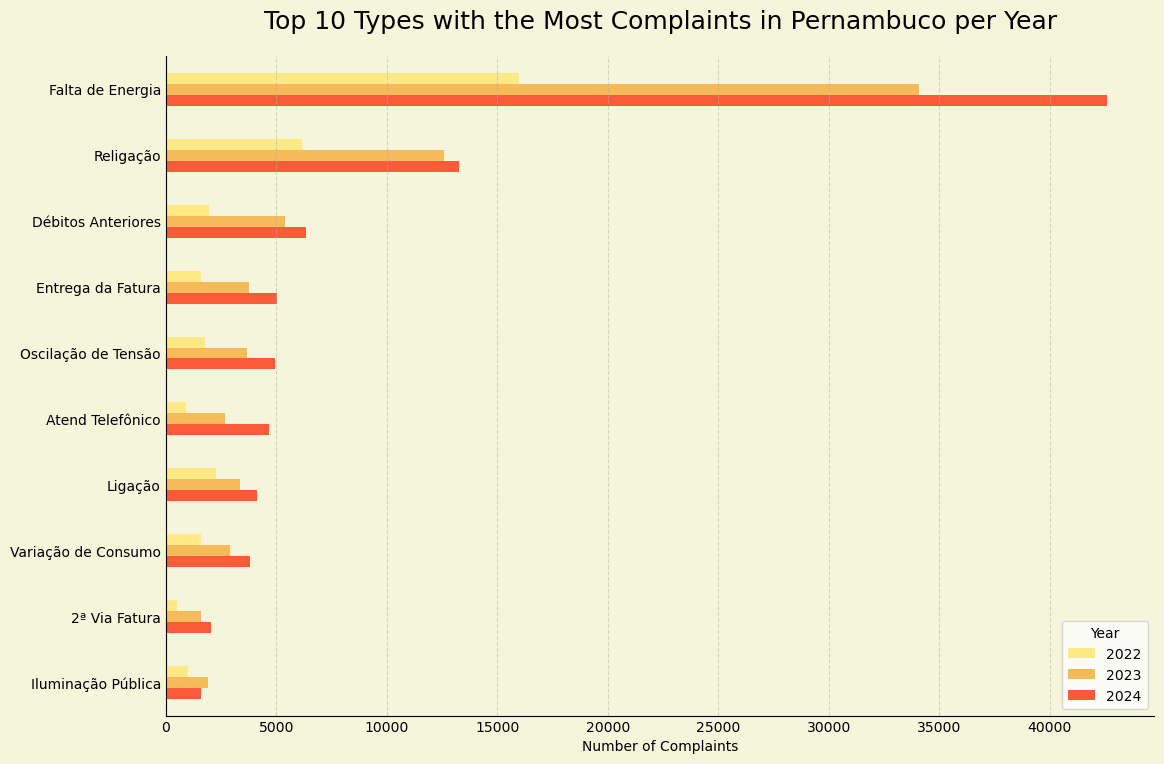

In [70]:
# Agrupar por Tipologia e Ano
tipologia_ano = df_pe.groupby(['NomTipologia', 'ano'])['NumQtdReclamacoesDia'].sum().unstack()

# Selecionar as 10 tipologias com mais reclamações somadas (em todos os anos)
top_10_tipologias = tipologia_ano.sum(axis=1).sort_values(ascending=False).head(10).index

# Filtrar apenas as top 10
tipologia_ano_top10 = tipologia_ano.loc[top_10_tipologias]

# Ordenar do maior para o menor com base em 2024 (ou soma geral, se preferir)
tipologia_ano_top10 = tipologia_ano_top10.sort_values(by=2024, ascending=False)

# Cores por ano
'''cores = {
    2022: '#ffe986',
    2023: '#f5bb5b',
    2024: '#fc5b39'
}'''
# Garantir ordenação correta das colunas
tipologia_ano_top10 = tipologia_ano_top10[sorted(tipologia_ano_top10.columns)]
cores_ordenadas = [cores[ano] for ano in sorted(tipologia_ano_top10.columns)]

# Criar figura e eixo
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')  # Fundo da figura

# Plotar gráfico horizontal com cores por ano
tipologia_ano_top10.plot(
    kind='barh',
    stacked=False,
    color=cores_ordenadas,
    ax=ax
)

# Estética e título
ax.set_title(
    'Top 10 Types with the Most Complaints in Pernambuco per Year',
    fontsize=18,
    pad=20
)
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('')

# Inverter Y para maior valor no topo
ax.invert_yaxis()

# Estética: fundo, grid, spines, ticks
ax.set_facecolor('#ffffff')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.gca().set_facecolor('#f5f5dc')
plt.gcf().set_facecolor('#f5f5dc')

plt.legend(title='Year')

plt.tight_layout(pad=2.0)
plt.savefig('images/p04_10_types_pernambuco_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

<br>
<br>
<br>
<br>
<br>
Serie temporal de Reclamações de Falta de Energia em Pernambuco.
2022 e 2023 apresentam uma certa estabilidade, embora 2023 tenha mais casos de reclamações do que 2022.
Contudo, há uma grande instabilidade no primeiro semestre de 2024, seguido por um segundo semestre mais estável com tendência de queda em relação aos anos precedentes.

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\3266821182.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pe_falta_energia['DtCriacao'] = pd.to_datetime(df_pe_falta_energia['DtCriacao'])
C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\3266821182.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pe_falta_energia['Ano'] = df_pe_falta_energia['DtCriacao'].dt.year
C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\3266821182.py:4: SettingWithCopyWarning: 
A value is tr

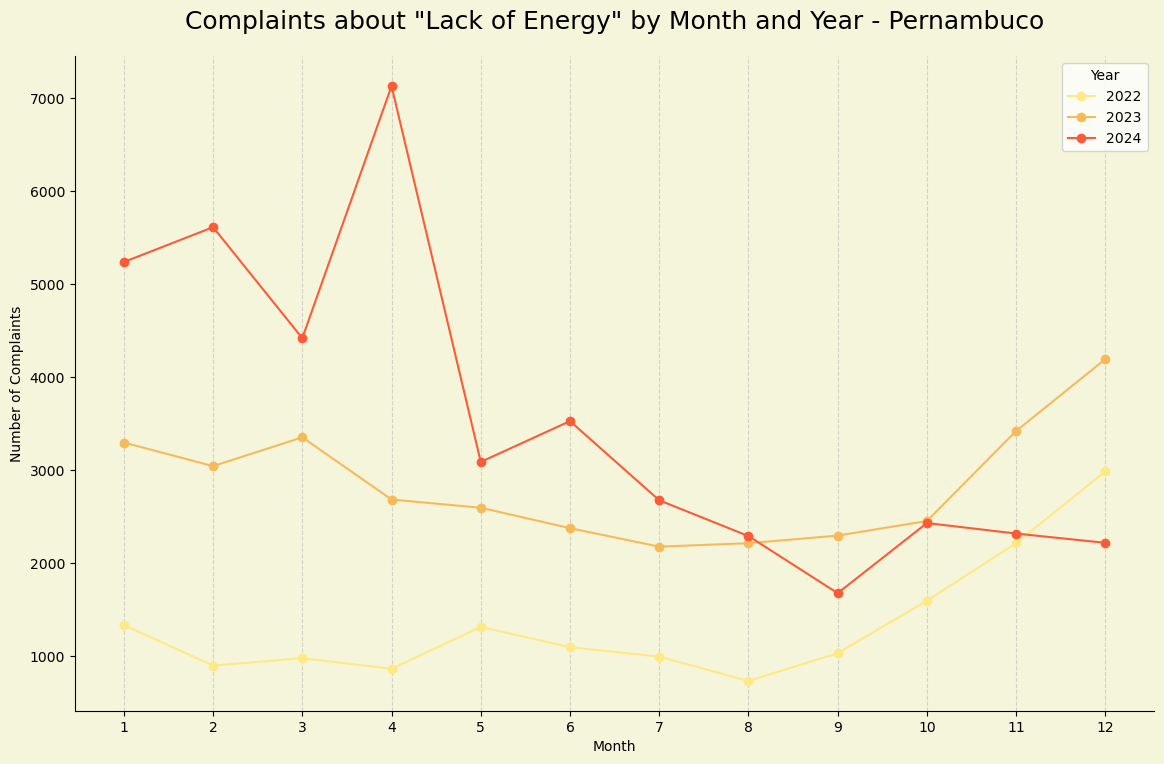

In [71]:
# Converte a data e extrai ano e mês
df_pe_falta_energia['DtCriacao'] = pd.to_datetime(df_pe_falta_energia['DtCriacao'])
df_pe_falta_energia['Ano'] = df_pe_falta_energia['DtCriacao'].dt.year
df_pe_falta_energia['Mes'] = df_pe_falta_energia['DtCriacao'].dt.month

# Agrupa por ano e mês
reclamacoes_mensais = df_pe_falta_energia.groupby(['Ano', 'Mes'])['NumQtdReclamacoesDia'].sum().unstack(0)

# Garantir a ordenação correta das colunas
reclamacoes_mensais = reclamacoes_mensais[sorted(reclamacoes_mensais.columns)]

# Criar figura e eixo com fundo bege claro
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')

# Plotar gráfico de linhas com cores definidas
reclamacoes_mensais.plot(
    marker='o',
    color=[cores[ano] for ano in sorted(reclamacoes_mensais.columns)],
    ax=ax
)

# Título com fonte maior e espaçamento
ax.set_title(
    'Complaints about "Lack of Energy" by Month and Year - Pernambuco',
    fontsize=18,
    pad=20
)

# Ajustar rótulos dos eixos
ax.set_xlabel('Month')
ax.set_ylabel('Number of Complaints')

# Configurar grid no eixo Y
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Ajustar a visualização das legendas
ax.legend(title='Year')

# Estética: fundo interno do gráfico e spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xticks(range(1, 13))

plt.gca().set_facecolor('#f5f5dc')
plt.gcf().set_facecolor('#f5f5dc') 

plt.tight_layout(pad=2.0)
plt.savefig('images/p05_10_types_pernambuco_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

<br>
<br>
<br>
<br>
<br>
10 Municípios com mais Reclamações de Falta de Energia em Pernambuco.
Recife se destaca pela a predominância e crescente quantidade de reclamações entre 2022 e 2024.

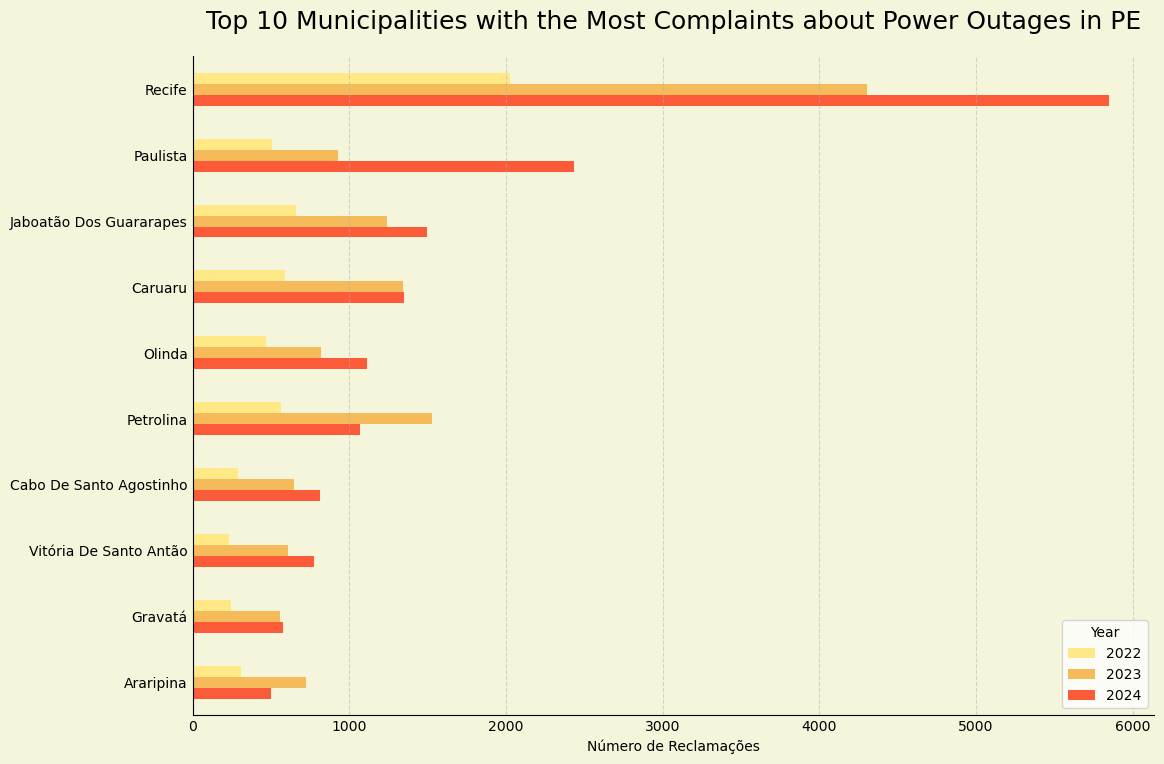

In [ ]:
# df_pe_falta_energia = df_NE[(df_NE['SigUF'] == 'PE') & (df_NE['NomTipologia'] == 'Falta de Energia')]

# Agrupar por município e ano
municipio_ano = df_pe_falta_energia.groupby(['NomMunicipio', 'ano'])['NumQtdReclamacoesDia'].sum().unstack()

# Selecionar os 10 municípios com mais reclamações somadas
top_10_municipios = municipio_ano.sum(axis=1).sort_values(ascending=False).head(10).index

# Filtrar apenas os top 10
municipio_ano_top10 = municipio_ano.loc[top_10_municipios]

# Ordenar pelos valores de 2024 para exibição
municipio_ano_top10 = municipio_ano_top10.sort_values(by=2024, ascending=False)

# Garantir ordenação correta das colunas
municipio_ano_top10 = municipio_ano_top10[sorted(municipio_ano_top10.columns)]
cores_ordenadas = [cores[ano] for ano in sorted(municipio_ano_top10.columns)]

# Criar figura e eixo
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')  # Fundo da figura

# Plotar gráfico de barras horizontais
municipio_ano_top10.plot(
    kind='barh',
    stacked=False,
    color=cores_ordenadas,
    ax=ax
)

ax.set_title(
    'Top 10 Municipalities with the Most Complaints about Lack of Energy in PE',
    fontsize=18,
    pad=20
)
ax.set_xlabel('Número de Reclamações')
ax.set_ylabel('')

# Inverter eixo Y para que o maior fique no topo
ax.invert_yaxis()

# Estética geral
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.gca().set_facecolor('#f5f5dc')
plt.gcf().set_facecolor('#f5f5dc') 

plt.legend(title='Year')

plt.tight_layout(pad=2.0)
plt.savefig('images/p06_10_types_municipalities_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

<br>
<br>
<br>
<br>
<br>
Serie temporal de Reclamações de Falta de Energia em Recife.
2022 e 2023 mostram um padrão próximo com 2023 tendo um aumento em relação a 2022.
Contudo, em 2024, a primeira metade do ano há uma grande variação de reclamações de Falta de Energia com uma aparente normalização no segundo semestre.
A instabilidade no cenário pernambucano parece estar diretamente ligada com a variação de reclamações no Recife.

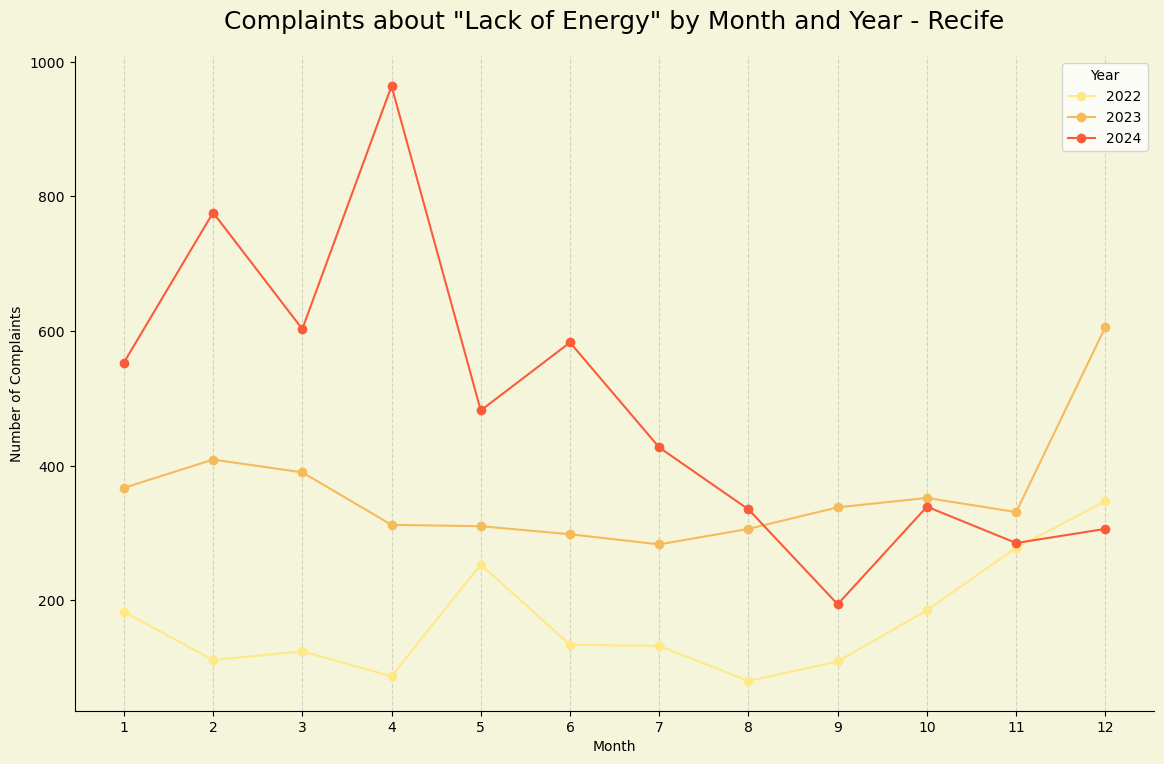

In [ ]:
# Converte a data e extrai ano e mês
df_recife_falta_energia['DtCriacao'] = pd.to_datetime(df_recife_falta_energia['DtCriacao'])
df_recife_falta_energia['Ano'] = df_recife_falta_energia['DtCriacao'].dt.year
df_recife_falta_energia['Mes'] = df_recife_falta_energia['DtCriacao'].dt.month

# Agrupa por ano e mês
reclamacoes_mensais = df_recife_falta_energia.groupby(['Ano', 'Mes'])['NumQtdReclamacoesDia'].sum().unstack(0)

# Garantir a ordenação correta das colunas
reclamacoes_mensais = reclamacoes_mensais[sorted(reclamacoes_mensais.columns)]

# Criar figura e eixo com fundo bege claro
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')

# Plotar gráfico de linhas com cores definidas
reclamacoes_mensais.plot(
    marker='o',
    color=[cores[ano] for ano in sorted(reclamacoes_mensais.columns)],
    ax=ax
)

# Título com fonte maior e espaçamento
ax.set_title(
    'Complaints about "Lack of Energy" by Month and Year - Recife',
    fontsize=18,
    pad=20
)

# Ajustar rótulos dos eixos
ax.set_xlabel('Month')
ax.set_ylabel('Number of Complaints')

# Configurar grid no eixo Y
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Ajustar a visualização das legendas
ax.legend(title='Year')

# Estética: fundo interno do gráfico e spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Definir os rótulos do eixo X para os meses
plt.xticks(range(1, 13))

plt.gca().set_facecolor('#f5f5dc') 
plt.gcf().set_facecolor('#f5f5dc')  

# Ajuste de layout para maior espaçamento
plt.tight_layout(pad=2.0)
plt.savefig('images/p07_recife_complaints.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

In [74]:
df_pe_falta_energia.head()

,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,...,DtCriacao,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia,id_municipio,populacao,Ano,Mes
0,01/12/2023,Enel CE,7047251000170,PE,2612505,Santa Cruz Do Capibaribe,Reclamações,Qualidade do Fornecimento,Falta de Energia,Procedente,...,2022-12-26,1,2022,12,December,26,2612505.0,97386.0,2022,12
7158,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2616407,Vitória De Santo Antão,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,2022-02-15,1,2022,2,February,15,2616407.0,135182.0,2022,2
7180,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2609402,Moreno,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,2022-06-06,1,2022,6,June,6,2609402.0,54637.0,2022,6
7188,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2613701,São Lourenço Da Mata,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,2022-06-09,1,2022,6,June,9,2613701.0,110765.0,2022,6
7196,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2613107,São Caitano,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,2022-06-25,1,2022,6,June,25,2613107.0,36982.0,2022,6


<br>
<br>
<br>
<br>
<br>
Há uma diferença em quantidade de ocorrências de reclamações e a proporção de reclamações por cidade.
Embora Recife seja a cidade com maior quantidade de pessoas e reclamações, proporcionalmente Vertente do Lério possui a maior quantidade de reclamações por habitante.
25 Municípios com mais Reclamações de Falta de Energia proporcionalmente a sua população em Pernambuco

C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\3712496890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pe_2024['populacao'] = pd.to_numeric(df_pe_2024['populacao'], errors='coerce')
C:\Users\guilhermevmmpg\AppData\Local\Temp\ipykernel_17348\3712496890.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25,


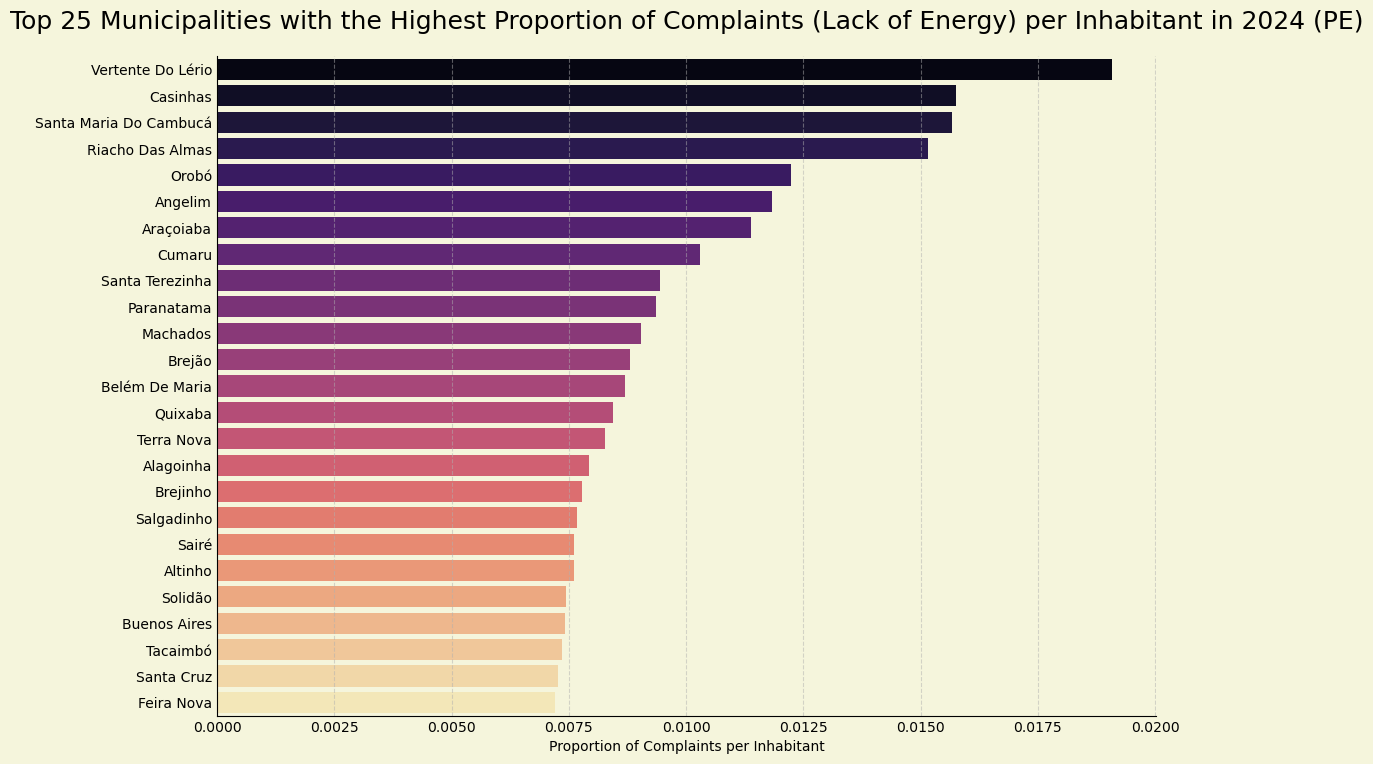

In [75]:
df_pe_2024 = df_pe_falta_energia[df_pe_falta_energia['ano'] == 2024]

df_pe_2024['populacao'] = pd.to_numeric(df_pe_2024['populacao'], errors='coerce')

# Agrupa por município e soma as reclamações
reclamacoes_por_municipio = df_pe_2024.groupby(['NomMunicipio', 'populacao'])['NumQtdReclamacoesDia'].sum().reset_index()

# Calcula a proporção
reclamacoes_por_municipio['proporcao'] = reclamacoes_por_municipio['NumQtdReclamacoesDia'] / reclamacoes_por_municipio['populacao']

# Ordena pelos municípios com maior proporção
reclamacoes_por_municipio = reclamacoes_por_municipio.sort_values(by='proporcao', ascending=False)

# Seleciona os top 25 municípios
top_25 = reclamacoes_por_municipio.head(25)

# Criar figura e eixo com fundo bege claro
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5dc')

# Plotar gráfico de barras horizontais usando o seaborn
sns.barplot(data=top_25,
            x='proporcao',
            y='NomMunicipio',
            palette='magma',  # Usando a paleta 'magma' para cores
            ax=ax)

# Título com fonte maior e espaçamento
ax.set_title(
    'Top 25 Municipalities with the Highest Proportion of Complaints (Lack of Energy) per Inhabitant in 2024 (PE)',
    fontsize=18,
    pad=20
)

# Ajustando rótulos dos eixos
ax.set_xlabel('Proportion of Complaints per Inhabitant')
ax.set_ylabel('')

# Estética: fundo interno do gráfico e grid
ax.set_facecolor('#ffffff')  # Fundo branco do gráfico
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Remover ticks dos eixos (mantendo os rótulos)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

# Remover spines laterais e superiores
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.gca().set_facecolor('#f5f5dc') 
plt.gcf().set_facecolor('#f5f5dc') 

plt.tight_layout(pad=2.0)
plt.savefig('images/p08_pe_complaints_proportion.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

<br>
<br>
<br>
<br>
<br>

# Aprendizado de Máquina

The **Local Outlier Factor (LOF)** is an anomaly detection algorithm (or outliers).

It is especially useful when you want to identify points that behave differently from the rest of the data, considering the local context of their surroundings.

The central idea of ​​LOF is to compare the local density of a point with the density of its closest neighbors.

If the density of a point is significantly lower than that of its neighbors, it is considered an outlier.

Based on other performance tests with the Isolation Forest and One-Class SVM models, LOF was deprecated since it showed a more conservative performance in identifying outliers.

<br>
<br>
<br>
<br>
<br>
Aqui foram desenvolvidos códigos para identificar os melhor hiperparâmetros, considerando o tamanho do datasets.

In [76]:
# Parâmetros para testar
n_neighbors_list = [5, 10, 15, 20, 25, 30]
contamination_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1]

# Dados de entrada
X = df_recife_falta_energia[['NumQtdReclamacoesDia']].values

# Escalar os dados - TESTE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Armazenar resultados
results = []

for n in n_neighbors_list:
    for c in contamination_list:
        lof = LOF(n_neighbors=n, contamination=c)
        lof.fit(X_scaled)
        y_pred = lof.predict(X_scaled)
        scores = lof.decision_function(X_scaled)  # valores maiores = mais anômalos

        # Estatísticas
        num_anomalies = np.sum(y_pred)
        avg_anomaly_score = np.mean(scores[y_pred == 1])
        std_anomaly_score = np.std(scores[y_pred == 1])

        results.append({
            'n_neighbors': n,
            'contamination': c,
            'num_anomalies': num_anomalies,
            'avg_anomaly_score': avg_anomaly_score,
            'std_anomaly_score': std_anomaly_score
        })

# Transformar em DataFrame
df_results = pd.DataFrame(results)
# print(df_results.sort_values('avg_anomaly_score', ascending=False))

num_rows = df_recife_falta_energia.shape[0]

# Limites dinâmicos (ex: entre 1% e 5%)
min_anomalias = int(0.005 * len(df_recife_falta_energia))  # 0.5% do total
max_anomalias = int(0.05 * len(df_recife_falta_energia))   # 5% do total

filtered_df = df_results[
    (df_results['avg_anomaly_score'] > 1.0) &
    (df_results['avg_anomaly_score'] < 3.0) &
    (df_results['num_anomalies'] >= min_anomalias) &   # ajustar conforme tamanho do dataset
    (df_results['num_anomalies'] <= max_anomalias) &  # ajustar conforme tamanho do dataset
    (df_results['std_anomaly_score'] < 1.0)
]

best_configs = filtered_df.sort_values(by='std_anomaly_score')

best_configs.head(20)

c:\Users\guilhermevmmpg\.conda\envs\python_for_data_science\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\guilhermevmmpg\.conda\envs\python_for_data_science\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\guilhermevmmpg\.conda\envs\python_for_data_science\Lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\guilhermevmmpg\.conda\envs\python_for_data_science\Lib\site-packages\numpy\_core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\guilhermevmmpg\.conda\envs\python_for_data_science\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  

,n_neighbors,contamination,num_anomalies,avg_anomaly_score,std_anomaly_score
0,5,0.01,14,1.618887,0.587904
1,5,0.02,14,1.618887,0.587904
2,5,0.03,14,1.618887,0.587904
3,5,0.04,14,1.618887,0.587904
4,5,0.05,14,1.618887,0.587904
5,5,0.10,14,1.618887,0.587904
17,15,0.10,41,1.516267,0.748277
14,15,0.03,41,1.516267,0.748277
16,15,0.05,41,1.516267,0.748277
15,15,0.04,41,1.516267,0.748277


<br>
<br>
<br>
<br>
<br>
Detecção de Anomalias Pernambuco para distinguir de quantidade de ocorrência que sejam consideradas padrões.

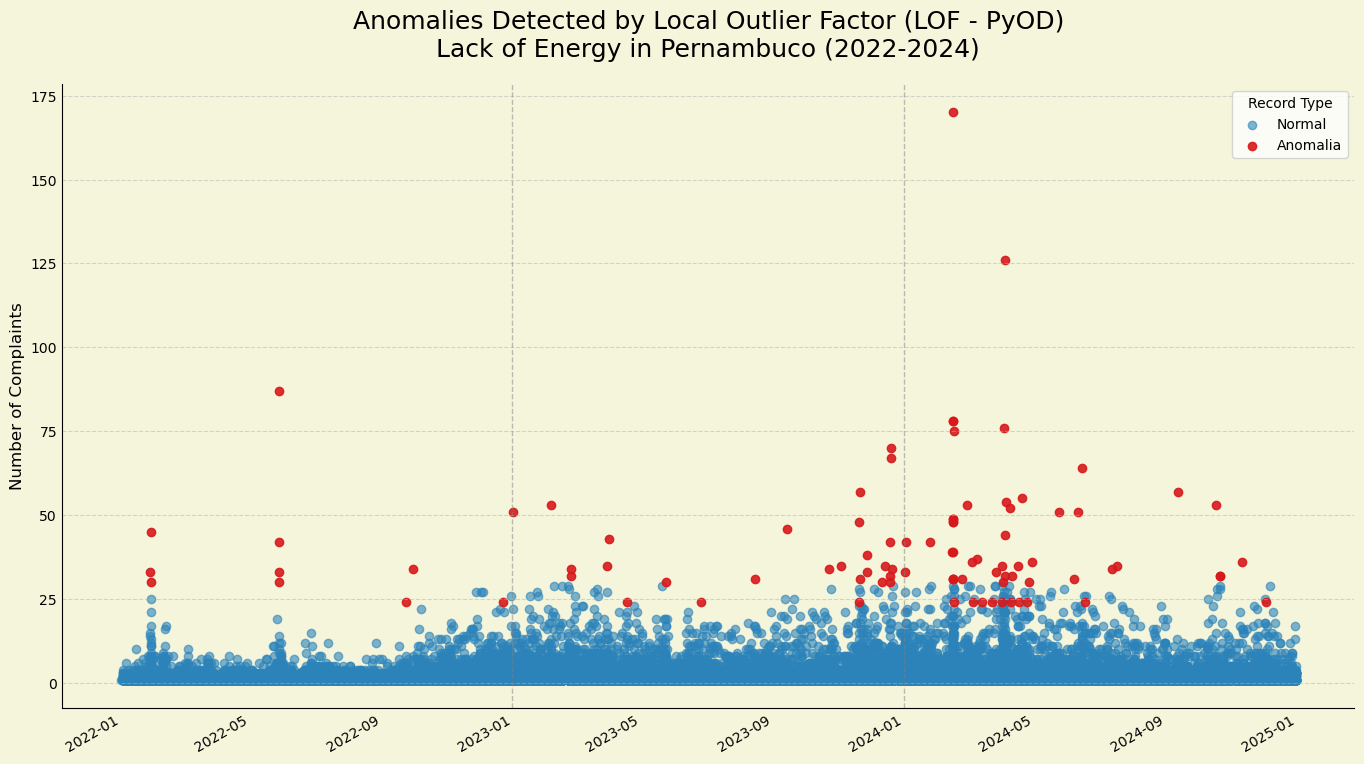

Number of Anomalies Detected by LOF (PyOD): 92


In [77]:
# Ordenar os dados por data
df_pe_falta_energia = df_pe_falta_energia.sort_values('DtCriacao')

# Selecionar a coluna relevante para detecção de anomalias
X = df_pe_falta_energia[['NumQtdReclamacoesDia']].values

# Inicializar o modelo LOF (pyod)
lof = LOF(n_neighbors=20, contamination=0.05)

# Treinar o modelo
lof.fit(X)

# Detectar anomalias (0 = normal, 1 = anomalia)
y_pred = lof.predict(X)
anomalies = (y_pred == 1)

# adiciona ao dataframe coluna com identificação da anomalia
df_pe_falta_energia['Anomalia'] = y_pred

# Adicionar coluna de anomalia (duplo check)
df_pe_falta_energia['Anomalia'] = anomalies

# Criar figura e eixo com fundo bege claro
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#f5f5dc')

# Pontos normais (azul)
ax.scatter(
    df_pe_falta_energia['DtCriacao'][~anomalies],
    df_pe_falta_energia['NumQtdReclamacoesDia'][~anomalies],
    color='#2b83ba', label='Normal', alpha=0.6
)

# Pontos anômalos (vermelho escuro)
ax.scatter(
    df_pe_falta_energia['DtCriacao'][anomalies],
    df_pe_falta_energia['NumQtdReclamacoesDia'][anomalies],
    color='#d7191c', label='Anomalia', alpha=0.9
)

# Título e rótulos com estilo
ax.set_title(
    'Anomalies Detected by Local Outlier Factor (LOF - PyOD)\nLack of Energy in Pernambuco (2022-2024)',
    fontsize=18,
    pad=20
)
# ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Number of Complaints', fontsize=12)

# Grid suave
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Estética do gráfico
ax.set_facecolor('#ffffff')  # Fundo branco do gráfico
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legenda estilizada
ax.legend(title='Record Type')

# Rotacionar datas
fig.autofmt_xdate()

# Fundo bege claro geral
plt.gca().set_facecolor('#f5f5dc')
plt.gcf().set_facecolor('#f5f5dc')

ax.axvline(pd.to_datetime('2023-01-01'), color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(pd.to_datetime('2024-01-01'), color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Layout mais espaçado
plt.tight_layout(pad=2.0)

plt.savefig('images/p09_pe_anomalies_detected_2022_2024.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

# Quantificar anomalias
num_anomalies = np.sum(anomalies)
print(f'Number of Anomalies Detected by LOF (PyOD): {num_anomalies}')

<br>
<br>
<br>
<br>
<br>
Aqui foi feito um recorte no ano de 2024 no Estado de Pernambuco para ter um detalhamento maior da densidade e dispersão das ocorrências anômalas.

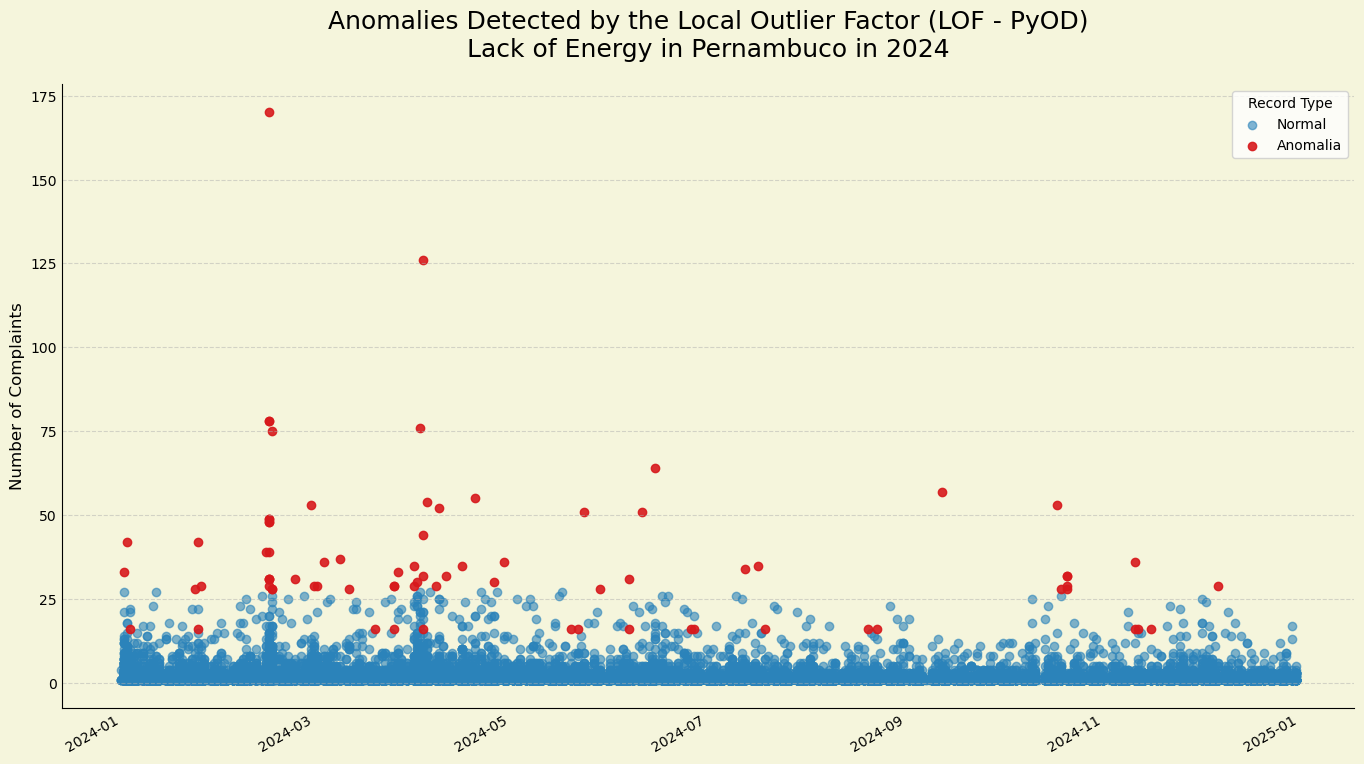

Number of Anomalies Detected by LOF (PyOD): 78


In [78]:

# Filtrar os dados de PE para "Falta de Energia"
# df_pe = df_NE[df_NE['SigUF'] == 'PE']
df_pe_falta_energia_2024 = df_pe_falta_energia[df_pe_falta_energia['ano'] == 2024]

# Ordenar os dados por data
df_pe_falta_energia_2024 = df_pe_falta_energia_2024.sort_values('DtCriacao')

# Selecionar a coluna relevante para detecção de anomalias
X = df_pe_falta_energia_2024[['NumQtdReclamacoesDia']].values

# Inicializar o modelo LOF (pyod)
lof = LOF(n_neighbors=20, contamination=0.05)

# Treinar o modelo
lof.fit(X)

# Detectar anomalias (0 = normal, 1 = anomalia)
y_pred = lof.predict(X)
anomalies = (y_pred == 1)

# adiciona ao dataframe coluna com identificação da anomalia
df_pe_falta_energia_2024['Anomalia'] = y_pred

# Adicionar coluna de anomalia (opcional)
df_pe_falta_energia_2024['Anomalia'] = anomalies

# Criar figura e eixo com fundo bege claro
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#f5f5dc')

# Pontos normais (azul)
ax.scatter(
    df_pe_falta_energia_2024['DtCriacao'][~anomalies],
    df_pe_falta_energia_2024['NumQtdReclamacoesDia'][~anomalies],
    color='#2b83ba', label='Normal', alpha=0.6
)

# Pontos anômalos (vermelho escuro)
ax.scatter(
    df_pe_falta_energia_2024['DtCriacao'][anomalies],
    df_pe_falta_energia_2024['NumQtdReclamacoesDia'][anomalies],
    color='#d7191c', label='Anomalia', alpha=0.9
)

# Título e rótulos com estilo
ax.set_title(
    'Anomalies Detected by the Local Outlier Factor (LOF - PyOD)\nLack of Energy in Pernambuco in 2024',
    fontsize=18,
    pad=20
)
# ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Number of Complaints', fontsize=12)

# Grid suave
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Estética do gráfico
# ax.set_facecolor('#ffffff')  # Fundo branco do gráfico
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legenda estilizada
ax.legend(title='Record Type')

# Rotacionar datas
fig.autofmt_xdate()

# Fundo bege claro geral
plt.gca().set_facecolor('#f5f5dc')  # Fundo do eixo
plt.gcf().set_facecolor('#f5f5dc')  # Fundo da figura

# Layout mais espaçado
plt.tight_layout(pad=2.0)

plt.savefig('images/p10_pe_anomalies_detected_only_2024.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

# Quantificar anomalias
num_anomalies = np.sum(anomalies)
print(f'Number of Anomalies Detected by LOF (PyOD): {num_anomalies}')

<br>
<br>
<br>
<br>
<br>
Visualização de ocorrência anômalas na cidade do Recife, apresentando 52 ocorrência anômalas entre janeiro de 2022 e dezembro de 2024.
Com concentração de tais ocorrências ao fim de 2023 e o meio de 2024.

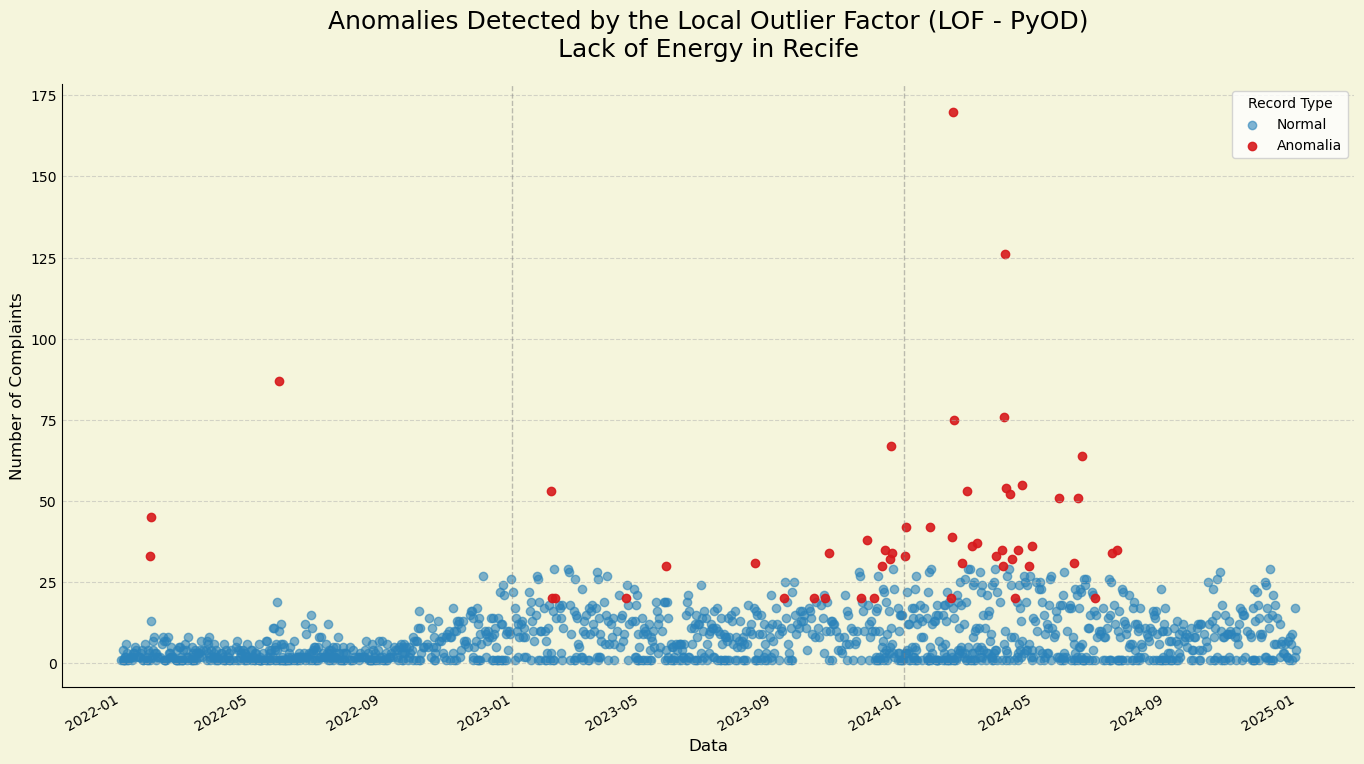

Number of Anomalies Detected by LOF (PyOD): 52


In [84]:
# Ordenar os dados por data
df_recife_falta_energia = df_recife_falta_energia.sort_values('DtCriacao')

# Selecionar a coluna relevante para detecção de anomalias
X = df_recife_falta_energia[['NumQtdReclamacoesDia']].values

# Inicializar o modelo LOF (pyod)
# lof = LOF(n_neighbors=20, contamination=0.05)
# lof = LOF(n_neighbors=5, contamination=0.01)
# lof = LOF(n_neighbors=15, contamination=0.01)
lof = LOF(n_neighbors=15, contamination=0.05)

# Treinar o modelo
lof.fit(X)

# Detectar anomalias (0 = normal, 1 = anomalia)
y_pred = lof.predict(X)
anomalies = (y_pred == 1)

# Adicionar coluna de anomalia (opcional)
df_recife_falta_energia['Anomalia'] = anomalies

# Criar figura e eixo com fundo bege claro
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#f5f5dc')

# Pontos normais (azul)
ax.scatter(
    df_recife_falta_energia['DtCriacao'][~anomalies],
    df_recife_falta_energia['NumQtdReclamacoesDia'][~anomalies],
    color='#2b83ba', label='Normal', alpha=0.6
)

# Pontos anômalos (vermelho escuro)
ax.scatter(
    df_recife_falta_energia['DtCriacao'][anomalies],
    df_recife_falta_energia['NumQtdReclamacoesDia'][anomalies],
    color='#d7191c', label='Anomalia', alpha=0.9
)

# Título e rótulos com estilo
ax.set_title(
    'Anomalies Detected by the Local Outlier Factor (LOF - PyOD)\nLack of Energy in Recife',
    fontsize=18,
    pad=20
)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Number of Complaints', fontsize=12)

# Grid suave
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Estética do gráfico
ax.set_facecolor('#ffffff')  # Fundo branco do gráfico
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legenda estilizada
ax.legend(title='Record Type')

# Rotacionar datas
fig.autofmt_xdate()

# Fundo bege claro geral
plt.gca().set_facecolor('#f5f5dc')  # Fundo do eixo
plt.gcf().set_facecolor('#f5f5dc')  # Fundo da figura

ax.axvline(pd.to_datetime('2023-01-01'), color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(pd.to_datetime('2024-01-01'), color='gray', linestyle='--', linewidth=1, alpha=0.5)


# Layout mais espaçado
plt.tight_layout(pad=2.0)

plt.savefig('images/p11_recife_anomalies_detected_only_2024.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

# Quantificar anomalias
num_anomalies = np.sum(anomalies)
print(f'Number of Anomalies Detected by LOF (PyOD): {num_anomalies}')

A solução ajudou na identificação de situações extraordinárias diante da demanda por reclamações diárias.

Contribui para identificar que a 'Falta de Energia' é o principal desafio a ser seguido pelo Governo do Estado.

E embora Recife seja a cidade com maior quantidade de reclamações, proporcionalmente ainda existem outras cidades menores que apresentam maior demanda à ANEEL.

Destaque que essas são dados de Reclamações para a ANEEL, há a possibilidade de outras ocorrências que não foram infomadas à autarquia e há a possibilidade de reclamações terem sido feitas exclusivamente para a Neoenergia.

<br>
<br>
<br>
<br>
<br>
Aferição das cidades com mais anomalias.

In [ ]:
df_pe_falta_energia.head()

,DatGeracaoConjuntoDados,SigAgente,NumCPFCNPJAgente,SigUF,CodigoMunicipio,NomMunicipio,NomCategoria,NomSubCategoria,NomTipologia,NomDecisao,...,NumQtdReclamacoesDia,ano,Mes_Numero,Mes_Nome,Dia,id_municipio,populacao,Ano,Mes,Anomalia
28862,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2611606,Recife,Reclamações,Qualidade do Fornecimento,Falta de Energia,Procedente,...,1,2022,1,January,1,2611606.0,1494586.0,2022,1,False
28551,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2607901,Jaboatão Dos Guararapes,Reclamações,Qualidade do Fornecimento,Falta de Energia,Procedente,...,1,2022,1,January,2,2607901.0,653793.0,2022,1,False
7633,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2603900,Carnaíba,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,1,2022,1,January,3,2603900.0,18437.0,2022,1,False
7487,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2606101,Glória Do Goitá,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,1,2022,1,January,3,2606101.0,29123.0,2022,1,False
7890,01/12/2023,Neoenergia Pernambuco,10835932000108,PE,2601706,Belo Jardim,Informação,Qualidade do Fornecimento,Falta de Energia,Sem decisão,...,1,2022,1,January,3,2601706.0,79143.0,2022,1,False


In [ ]:
print(df_pe_falta_energia['Anomalia'].value_counts())

Anomalia
False    43970
True        92
Name: count, dtype: int64


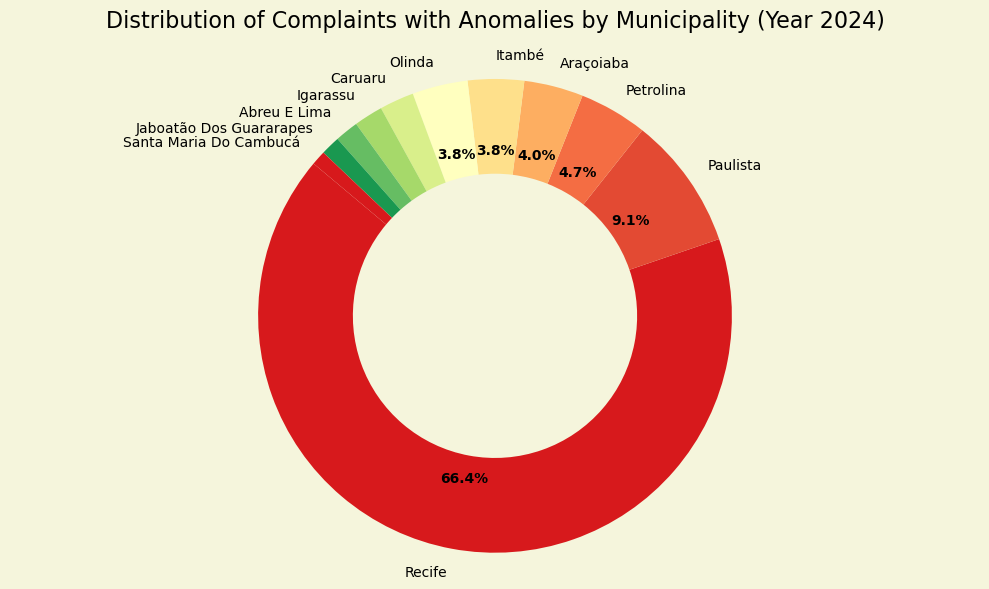

In [85]:
df_anomalias_2024 = df_pe_falta_energia[(df_pe_falta_energia['Anomalia'] == True) & (df_pe_falta_energia['Ano'] == 2024)]

# Soma das reclamações por município
reclamacoes_por_municipio = df_anomalias_2024.groupby('NomMunicipio')['NumQtdReclamacoesDia'].sum()
reclamacoes_por_municipio = reclamacoes_por_municipio.sort_values(ascending=False)

# Paleta de cores
cores = ['#d7191c', '#e34a33', '#f46d43', '#fdae61', '#fee08b', '#ffffbf', '#d9ef8b', '#a6d96a', '#66bd63', '#1a9850']
cores = cores[:len(reclamacoes_por_municipio)]

# Criando o gráfico de rosca
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f5f5dc')

# Gerando os wedges (fatias)
wedges, texts = ax.pie(
    reclamacoes_por_municipio,
    labels=reclamacoes_por_municipio.index,
    startangle=140,
    wedgeprops={'width': 0.4},
    colors=cores
)

# Calcula porcentagens
total = sum(reclamacoes_por_municipio)
porcentagens = 100. * reclamacoes_por_municipio / total

# Adiciona texto apenas para os 6 maiores
for i, (pct, wedge) in enumerate(zip(porcentagens, wedges)):
    if i < 6:
        ang = (wedge.theta2 + wedge.theta1) / 2.  # Ângulo médio da fatia
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        ax.text(
            x * 0.7, y * 0.7,  # 0.7 posiciona no centro da fatia (meio da rosca)
            f'{pct:.1f}%',
            ha='center', va='center',
            fontsize=10, weight='bold', color='black'
        )

# Título
ax.set_title(
    'Distribution of Complaints with Anomalies by Municipality (Year 2024)',
    fontsize=16,
    pad=20
)

# Estética de fundo e layout
ax.set_facecolor('#ffffff')
plt.gca().set_facecolor('#f5f5dc')
plt.gcf().set_facecolor('#f5f5dc')
plt.axis('equal')
plt.tight_layout()
plt.savefig('images/p12_pe_proportion_complaints_2024.png', dpi=300, bbox_inches='tight', facecolor='#f5f5dc')
plt.show()

Foi identificado que no ano de 2024 o município do Recife concentrou mais da metade das ocorrências de reclamações ou pedidos de informações ligados a 'Falta de Energia' para a ANEEL.

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
Fim.